# 02 - full available universe, no BTC, $1000 account

Run the current `volume_weighted_breakout` strategy over every symbol with local 1m data, excluding `BTCUSDT`, for `2024-01-01` -> `2026-01-01`. Equity and benchmark are rebased to `$1000` for display.

This is a diagnostic universe stress-test. The repo universe is currently-listed Bybit perps, so broad alt runs carry survivorship bias; use this to inspect behavior, not as a clean validation claim.

In [1]:
import json
import sys; sys.path.insert(0, ".")   # cwd = notebooks/volume_weighted_breakout
from _lab import *

symbols = [s for s in list_symbols() if s != "BTCUSDT"]
start, end = "2024-01-01", "2026-01-01"
initial_cash = 1000.0

print("strategy:", strategy.__name__)
print("TF:", strategy.DEFAULT_TF)
print(f"symbols ({len(symbols)}):", symbols)

strategy: strategy_volume_weighted_breakout
TF: 4h
symbols (33): ['1000PEPEUSDT', 'AAVEUSDT', 'ADAUSDT', 'ALGOUSDT', 'ARBUSDT', 'AVAXUSDT', 'BCHUSDT', 'BNBUSDT', 'DASHUSDT', 'DOGEUSDT', 'DOTUSDT', 'ENJUSDT', 'ETHUSDT', 'HBARUSDT', 'INJUSDT', 'JTOUSDT', 'LINKUSDT', 'LTCUSDT', 'MNTUSDT', 'NEARUSDT', 'OPUSDT', 'PAXGUSDT', 'SOLUSDT', 'SUIUSDT', 'TIAUSDT', 'TONUSDT', 'TRXUSDT', 'UNIUSDT', 'WLDUSDT', 'XLMUSDT', 'XMRUSDT', 'XRPUSDT', 'ZECUSDT']


In [2]:
coverage_table = pd.DataFrame(
    [(sym, *coverage(sym)) for sym in symbols],
    columns=["symbol", "first_month", "last_month", "n_months"],
).set_index("symbol")
coverage_table

,first_month,last_month,n_months
symbol,,,
1000PEPEUSDT,2024-01,2026-05,29
AAVEUSDT,2024-01,2026-05,29
ADAUSDT,2024-01,2026-05,29
ALGOUSDT,2024-01,2026-05,29
ARBUSDT,2024-01,2026-05,29
AVAXUSDT,2024-01,2026-05,29
BCHUSDT,2024-01,2026-05,29
BNBUSDT,2024-01,2026-05,29
DASHUSDT,2024-01,2026-05,29


In [3]:
result = run_pair(symbols, start, end, return_curves=True)
metrics_frame(result)

,sharpe,sortino,max_dd,total_return,n_trades,pct_time_in_position,profit_factor
split,,,,,,,
train,0.951875,0.976221,0.078828,0.218288,1551,52.188450,1.302558
oos,-0.586907,-0.451756,0.114549,-0.045971,439,48.540146,0.819345


In [4]:
curves = result["curves"]
equity = rebase(curves["equity"], initial_cash)
benchmark = rebase(curves["benchmark"], initial_cash)
raw_equity = rebase(curves["raw_equity"], initial_cash)
dd = drawdown(equity)
cutoff = curves["split_cutoff"]

summary = pd.Series({
    "n_symbols": len(symbols),
    "start_equity": equity.iloc[0],
    "end_equity": equity.iloc[-1],
    "total_return": equity.iloc[-1] / equity.iloc[0] - 1.0,
    "max_drawdown": dd.min(),
    "benchmark_end": benchmark.iloc[-1],
    "bars": len(equity),
})
summary

n_symbols          33.000000
start_equity     1000.000000
end_equity       1162.421414
total_return        0.162421
max_drawdown       -0.143725
benchmark_end    1710.855777
bars             4386.000000
dtype: float64

[saved] notebooks\volume_weighted_breakout\_out\02_full_universe_no_btc_1000_equity_drawdown.png


WindowsPath('C:/Users/digbi/Projects/research-lab/notebooks/volume_weighted_breakout/_out/02_full_universe_no_btc_1000_equity_drawdown.png')

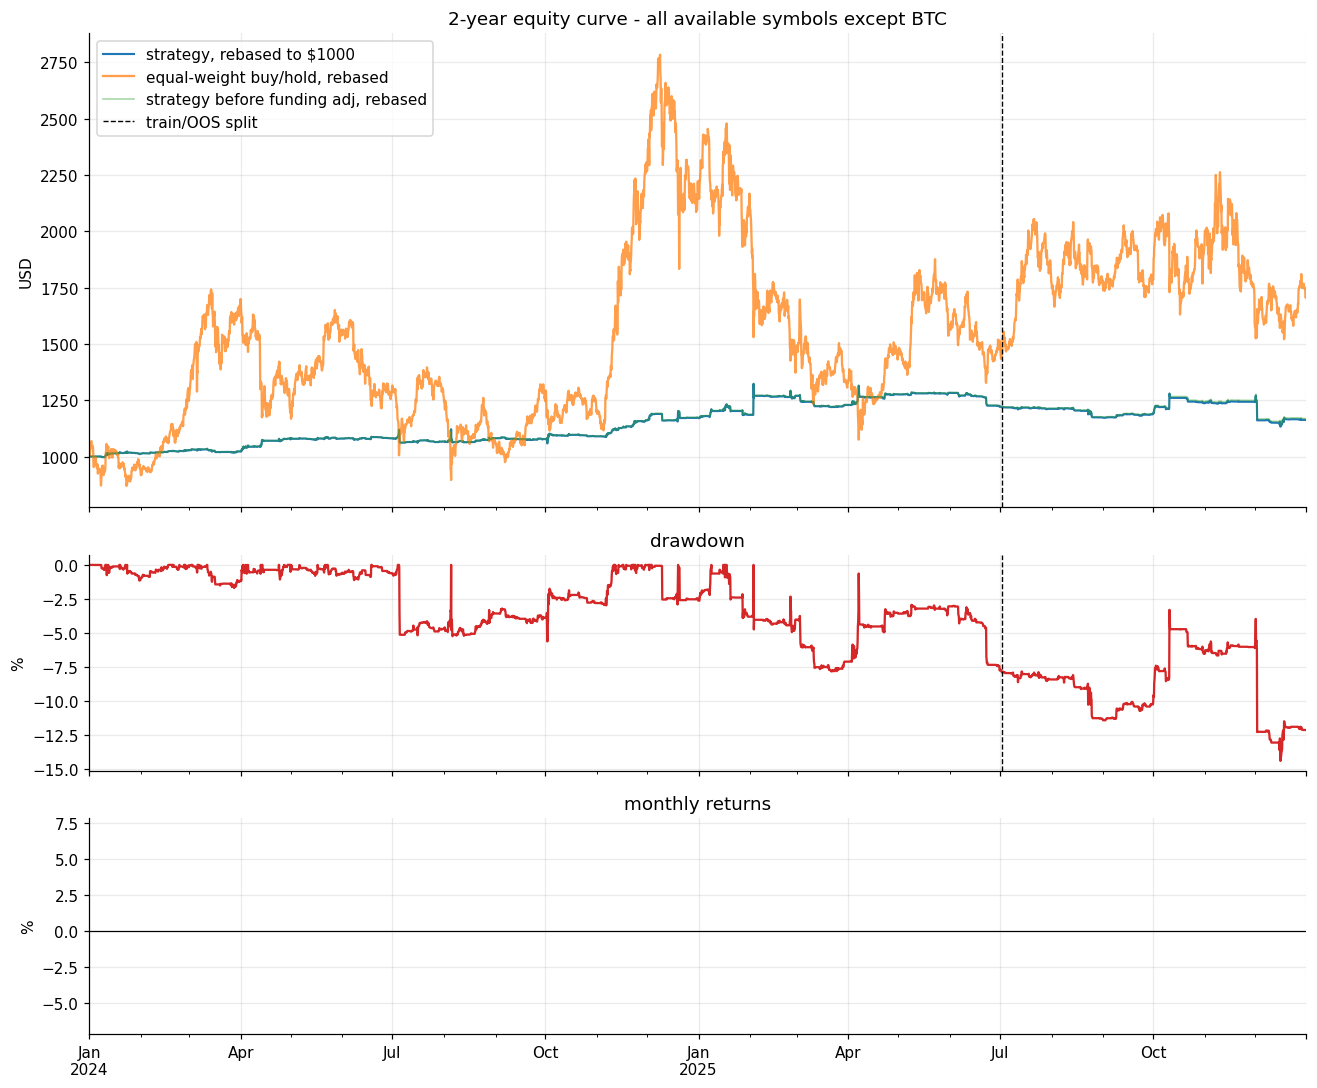

In [5]:
fig, ax = plt.subplots(3, 1, figsize=(12, 10), sharex=True, gridspec_kw={"height_ratios": [2.2, 1.0, 1.0]})

equity.plot(ax=ax[0], label="strategy, rebased to $1000", lw=1.4)
benchmark.plot(ax=ax[0], label="equal-weight buy/hold, rebased", alpha=0.75)
raw_equity.plot(ax=ax[0], label="strategy before funding adj, rebased", alpha=0.45, lw=1.0)
ax[0].axvline(cutoff, color="k", lw=0.9, ls="--", label="train/OOS split")
ax[0].set_title("2-year equity curve - all available symbols except BTC")
ax[0].set_ylabel("USD")
ax[0].legend(loc="best")

(dd * 100).plot(ax=ax[1], color="C3")
ax[1].axvline(cutoff, color="k", lw=0.9, ls="--")
ax[1].set_title("drawdown")
ax[1].set_ylabel("%")

mret = monthly_returns(equity) * 100
colors = np.where(mret >= 0, "C2", "C3")
ax[2].bar(mret.index, mret.values, width=20, color=colors, alpha=0.8)
ax[2].axhline(0, color="k", lw=0.8)
ax[2].axvline(cutoff, color="k", lw=0.9, ls="--")
ax[2].set_title("monthly returns")
ax[2].set_ylabel("%")

show("02_full_universe_no_btc_1000_equity_drawdown")

[saved] notebooks\volume_weighted_breakout\_out\02_full_universe_no_btc_1000_exposure.png


WindowsPath('C:/Users/digbi/Projects/research-lab/notebooks/volume_weighted_breakout/_out/02_full_universe_no_btc_1000_exposure.png')

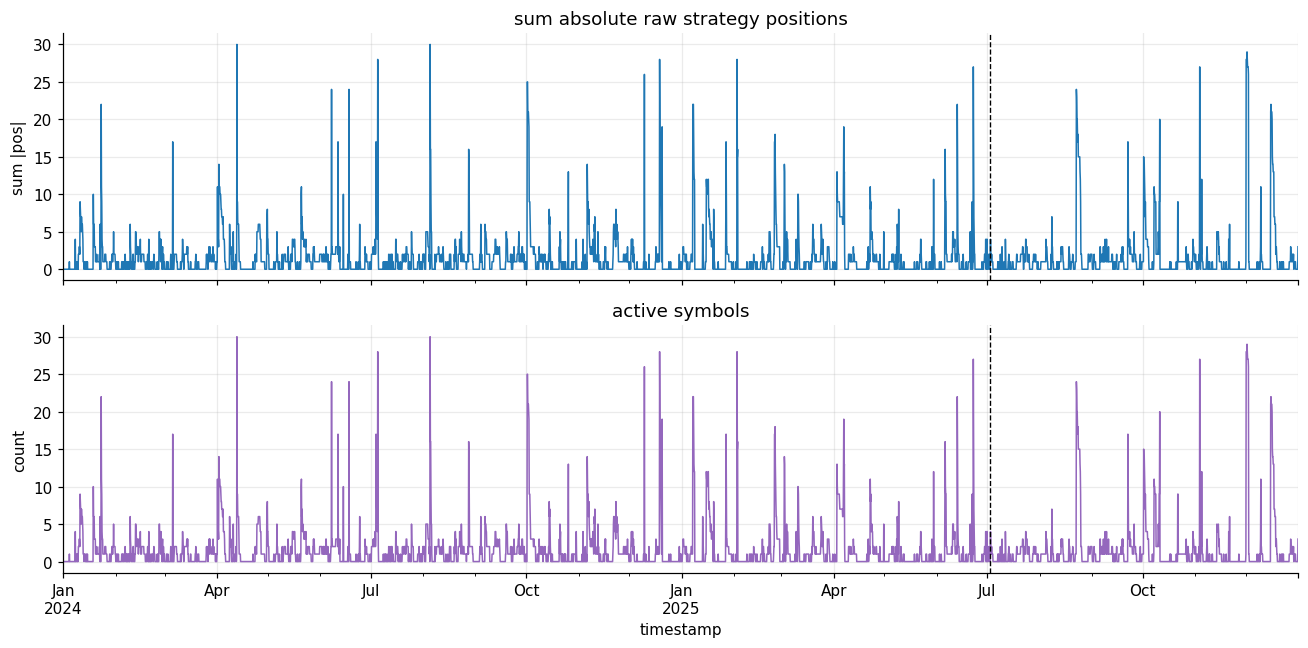

In [6]:
signals = generate_pair_signals(symbols, start, end)
pos = positions_wide(signals).reindex(equity.index).ffill().fillna(0.0)
exposure = pos.abs().sum(axis=1)
active_symbols = (pos != 0).sum(axis=1)

fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
exposure.plot(ax=ax[0], lw=1.0)
ax[0].axvline(cutoff, color="k", lw=0.9, ls="--")
ax[0].set_title("sum absolute raw strategy positions")
ax[0].set_ylabel("sum |pos|")

active_symbols.plot(ax=ax[1], lw=1.0, color="C4")
ax[1].axvline(cutoff, color="k", lw=0.9, ls="--")
ax[1].set_title("active symbols")
ax[1].set_ylabel("count")

show("02_full_universe_no_btc_1000_exposure")

In [7]:
trades = curves["trades"].copy()
print("trades:", len(trades))
trades.head(10)

trades: 1990


,entry_time,exit_time,symbol,direction,size,entry_price,exit_price,pnl_quote,return_pct,duration_hours,slice,entry_notional_usd,entry_daily_volume_usd,participation_pct
0,2024-01-11 00:00:00+00:00,2024-01-11 04:00:00+00:00,1000PEPEUSDT,Long,219694.442620,0.001389,0.001437,10.317590,0.033822,4.0,train,305.054267,1.772630e+08,0.000172
1,2024-01-23 12:00:00+00:00,2024-01-24 00:00:00+00:00,1000PEPEUSDT,Short,307910.546040,0.001015,0.001029,-4.432682,-0.014177,12.0,train,312.671029,5.611505e+07,0.000557
2,2024-02-05 12:00:00+00:00,2024-02-05 16:00:00+00:00,1000PEPEUSDT,Long,329270.135397,0.000933,0.000926,-2.900370,-0.009436,4.0,train,307.371478,5.969499e+07,0.000515
3,2024-02-12 20:00:00+00:00,2024-02-13 04:00:00+00:00,1000PEPEUSDT,Long,285746.972233,0.001081,0.001124,12.067554,0.039078,8.0,train,308.809056,4.832151e+07,0.000639
4,2024-02-14 16:00:00+00:00,2024-02-14 20:00:00+00:00,1000PEPEUSDT,Long,257717.060305,0.001199,0.001248,12.347033,0.039957,4.0,train,309.007881,1.362605e+08,0.000227
5,2024-02-23 12:00:00+00:00,2024-02-23 16:00:00+00:00,1000PEPEUSDT,Long,254453.455456,0.001217,0.001239,5.242790,0.016936,4.0,train,309.573583,2.869455e+08,0.000108
6,2024-02-27 00:00:00+00:00,2024-02-27 04:00:00+00:00,1000PEPEUSDT,Long,148283.314634,0.002100,0.002040,-9.221917,-0.029613,4.0,train,311.411270,1.262803e+09,0.000025
7,2024-02-27 20:00:00+00:00,2024-02-28 00:00:00+00:00,1000PEPEUSDT,Long,116912.123328,0.002666,0.002607,-7.181644,-0.023041,4.0,train,311.683812,1.262803e+09,0.000025
8,2024-03-25 16:00:00+00:00,2024-03-26 16:00:00+00:00,1000PEPEUSDT,Long,39535.056285,0.008362,0.007934,-17.276735,-0.052258,24.0,train,330.601646,4.748978e+08,0.000070
9,2024-04-08 12:00:00+00:00,2024-04-08 16:00:00+00:00,1000PEPEUSDT,Long,41473.541571,0.007632,0.007794,6.377521,0.020149,4.0,train,316.516244,3.386349e+08,0.000093


In [8]:
if len(trades):
    by_symbol = trades.groupby("symbol").agg(
        n=("symbol", "size"),
        pnl_quote=("pnl_quote", "sum"),
        avg_return=("return_pct", "mean"),
        win_rate=("return_pct", lambda s: (s > 0).mean()),
        avg_duration_h=("duration_hours", "mean"),
    ).sort_values("pnl_quote", ascending=False)
    display(by_symbol)
    display(by_symbol.tail(10))
    display(trades.tail(10))
else:
    print("No trades in this period.")

,n,pnl_quote,avg_return,win_rate,avg_duration_h
symbol,,,,,
ZECUSDT,66,252.296296,0.010762,0.545455,9.333333
1000PEPEUSDT,49,233.213402,0.012048,0.510204,12.326531
ALGOUSDT,65,219.719153,0.009520,0.507692,10.461538
SUIUSDT,51,201.354570,0.010706,0.490196,13.803922
BCHUSDT,69,185.299085,0.007603,0.536232,15.536232
AAVEUSDT,58,169.232009,0.007814,0.620690,12.965517
SOLUSDT,57,154.518921,0.006997,0.526316,13.964912
TIAUSDT,54,125.293298,0.003953,0.481481,14.370370
MNTUSDT,28,125.040396,0.014178,0.642857,8.857143


,n,pnl_quote,avg_return,win_rate,avg_duration_h
symbol,,,,,
XMRUSDT,48,-4.640207,-0.000593,0.354167,6.416667
BNBUSDT,67,-8.548466,-0.000096,0.507463,10.925373
PAXGUSDT,68,-50.034560,-0.002099,0.367647,19.294118
UNIUSDT,62,-56.334791,-0.001738,0.387097,17.161290
INJUSDT,47,-70.192022,-0.005339,0.446809,14.553191
DASHUSDT,70,-84.844851,-0.003252,0.428571,9.771429
TONUSDT,67,-84.927512,-0.003672,0.373134,12.477612
JTOUSDT,57,-97.299810,-0.006519,0.385965,10.315789
DOTUSDT,51,-107.427184,-0.005921,0.352941,13.019608


,entry_time,exit_time,symbol,direction,size,entry_price,exit_price,pnl_quote,return_pct,duration_hours,slice,entry_notional_usd,entry_daily_volume_usd,participation_pct
1980,2025-09-06 20:00:00+00:00,2025-09-07 00:00:00+00:00,ZECUSDT,Long,7.502308,47.564756,46.765323,-6.386824,-0.017898,4.0,oos,356.845449,3.934216e+06,0.009070
1981,2025-09-23 16:00:00+00:00,2025-09-24 20:00:00+00:00,ZECUSDT,Long,6.996184,53.101828,58.630996,38.253134,0.102967,28.0,oos,371.510147,4.255793e+06,0.008730
1982,2025-09-29 04:00:00+00:00,2025-09-29 08:00:00+00:00,ZECUSDT,Long,5.447743,66.106610,68.893110,14.775642,0.041028,4.0,oos,360.131828,2.669907e+07,0.001349
1983,2025-09-29 12:00:00+00:00,2025-09-29 16:00:00+00:00,ZECUSDT,Long,5.315400,67.836783,69.533046,8.614719,0.023891,4.0,oos,360.579619,2.669907e+07,0.001351
1984,2025-09-30 16:00:00+00:00,2025-10-01 08:00:00+00:00,ZECUSDT,Long,4.864199,75.494184,93.182748,85.589427,0.233075,16.0,oos,367.218723,2.850977e+07,0.001288
1985,2025-10-01 12:00:00+00:00,2025-10-01 16:00:00+00:00,ZECUSDT,Long,3.922673,92.549254,118.938105,103.058545,0.283876,4.0,oos,363.040421,2.112979e+08,0.000172
1986,2025-10-01 20:00:00+00:00,2025-10-02 08:00:00+00:00,ZECUSDT,Long,3.045324,120.852084,142.068409,64.170207,0.174360,12.0,oos,368.033730,2.112979e+08,0.000174
1987,2025-10-26 16:00:00+00:00,2025-10-26 20:00:00+00:00,ZECUSDT,Long,1.081430,350.355032,324.747522,-28.094262,-0.074150,4.0,oos,378.884314,3.211804e+08,0.000118
1988,2025-12-01 04:00:00+00:00,2025-12-02 12:00:00+00:00,ZECUSDT,Short,1.214986,355.896449,371.527300,-19.477369,-0.045044,32.0,oos,432.409374,4.145251e+08,0.000104
1989,2025-12-27 12:00:00+00:00,2025-12-29 08:00:00+00:00,ZECUSDT,Long,0.720550,519.886695,523.236947,2.000633,0.005341,44.0,oos,374.604601,2.599844e+08,0.000144


In [9]:
# Full metric payload, excluding the large curve/trade objects already shown above.
print(json.dumps(clean_metrics(result), indent=2, default=str))

{
  "strategy": "volume_weighted_breakout",
  "params": {
    "breakout_lookback": 20,
    "volume_ma": 20,
    "volume_mult": 3.0,
    "atr_period": 14,
    "take_atr": 2.5,
    "max_hold_bars": 30
  },
  "symbols": [
    "1000PEPEUSDT",
    "AAVEUSDT",
    "ADAUSDT",
    "ALGOUSDT",
    "ARBUSDT",
    "AVAXUSDT",
    "BCHUSDT",
    "BNBUSDT",
    "DASHUSDT",
    "DOGEUSDT",
    "DOTUSDT",
    "ENJUSDT",
    "ETHUSDT",
    "HBARUSDT",
    "INJUSDT",
    "JTOUSDT",
    "LINKUSDT",
    "LTCUSDT",
    "MNTUSDT",
    "NEARUSDT",
    "OPUSDT",
    "PAXGUSDT",
    "SOLUSDT",
    "SUIUSDT",
    "TIAUSDT",
    "TONUSDT",
    "TRXUSDT",
    "UNIUSDT",
    "WLDUSDT",
    "XLMUSDT",
    "XMRUSDT",
    "XRPUSDT",
    "ZECUSDT"
  ],
  "tf": "4h",
  "period": [
    "2024-01-01",
    "2026-01-01"
  ],
  "main": {
    "train": {
      "sharpe": 0.9518751286588528,
      "bench_sharpe": 0.7168860066217636,
      "alpha_sharpe": 0.23498912203708922,
      "information_ratio": -0.5087833147283549,
     